In [1]:
import time
import copy
import numpy as np
import joblib
from xgboost import XGBClassifier
from pathlib import Path
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [2]:
BASE_ENV = Path().resolve().parent
ART= BASE_ENV / 'artifacts'

In [3]:
X_train = np.load(ART / 'datasets/train/X.npy')
y_train = np.load(ART / 'datasets/train/y.npy')
X_val = np.load(ART / 'datasets/val/X.npy')
y_val = np.load(ART / 'datasets/val/y.npy')
X_test = np.load(ART / 'datasets/test/X.npy')
y_test = np.load(ART / 'datasets/test/y.npy')


In [4]:
encoder = joblib.load(ART / 'preprocessors/encoder.joblib')
num_of_classes = len(encoder.classes_)

In [5]:
X_proto, _, y_proto, _ = train_test_split(
    X_train, y_train, 
    train_size=0.05,           # Keep exactly 5%
    stratify=y_train,  # CRITICAL: Maintain the exact ratio of attack types
    random_state=42
)

In [6]:
param_grid = {
    'max_depth': [3, 6, 9],              # Shallow vs Deep trees
    'learning_rate': [0.01, 0.1, 0.3],   # Slow vs Fast learning
    'n_estimators': [50, 100, 200],      # Number of trees
    'subsample': [0.8, 1.0]              # Prevent overfitting by using 80% of data per tree
}

In [7]:
xgb_tuner = XGBClassifier(objective='multi:softprob', random_state=42, n_jobs=-1)

# Set up the search engine
random_search = RandomizedSearchCV(
    estimator=xgb_tuner,
    param_distributions=param_grid,
    n_iter=10,             # Test exactly 10 random combinations from the menu
    scoring='accuracy',
    cv=3,                  # Cross-validation: double checks the score 3 times per test
    verbose=2,             # Prints progress so you aren't staring at a blank screen
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

In [8]:
random_search.fit(X_proto, y_proto)
print("Best Hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END learning_rate=0.3, max_depth=9, n_estimators=50, subsample=1.0; total time=   1.5s
[CV] END learning_rate=0.3, max_depth=9, n_estimators=50, subsample=0.8; total time=   1.4s
[CV] END learning_rate=0.3, max_depth=6, n_estimators=100, subsample=0.8; total time=   1.7s
[CV] END learning_rate=0.3, max_depth=9, n_estimators=50, subsample=0.8; total time=   1.7s
[CV] END learning_rate=0.3, max_depth=9, n_estimators=50, subsample=1.0; total time=   1.8s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1.0; total time=   1.4s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1.0; total time=   1.7s
[CV] END learning_rate=0.3, max_depth=6, n_estimators=100, subsample=0.8; total time=   1.9s
[CV] END learning_rate=0.3, max_depth=9, n_estimators=50, subsample=1.0; total time=   1.6s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1.0; total time=   1.9s
[CV] END learning

In [6]:
xgb_final = XGBClassifier(
    objective='multi:softprob', 
    num_class=num_of_classes,
    max_depth=9,             # Injected from Tuner
    learning_rate=0.3,       # Injected from Tuner
    n_estimators=50,         # Injected from Tuner
    subsample=1.0,           # Injected from Tuner
    random_state=42,
    n_jobs=-1                # Use all CPU cores
)

In [7]:
xgb_final.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
y_pred = xgb_final.predict(X_test)

In [9]:
y_test_labels = encoder.inverse_transform(y_test)
y_pred_labels = encoder.inverse_transform(y_pred)

In [10]:
accuracy_score(y_test_labels, y_pred_labels)

0.9999872842292653

In [11]:
print("\nDetailed Classification Report:")
print(classification_report(y_test_labels, y_pred_labels, digits=4))


Detailed Classification Report:
                precision    recall  f1-score   support

        Benign     1.0000    1.0000    1.0000    100143
FTP-BruteForce     0.9999    1.0000    1.0000     29004
SSH-Bruteforce     1.0000    0.9999    1.0000     28138

      accuracy                         1.0000    157285
     macro avg     1.0000    1.0000    1.0000    157285
  weighted avg     1.0000    1.0000    1.0000    157285



In [15]:
xgb_final.save_model(ART / 'models/xgb_CICIDS2018.json')

Top 10 Features Driving the 100% Accuracy:
              Feature  Importance
31  Fwd_Act_Data_Pkts    0.633899
26       URG_Flag_Cnt    0.295164
32   Fwd_Seg_Size_Min    0.054659
30  Init_Bwd_Win_Byts    0.015686
10      Flow_IAT_Mean    0.000274
18         Fwd_Pkts_s    0.000151
0       Flow_Duration    0.000053
13       Flow_IAT_Min    0.000044
4     TotLen_Bwd_Pkts    0.000026
16     Fwd_Header_Len    0.000017


/tmp/ipykernel_133808/3269289436.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


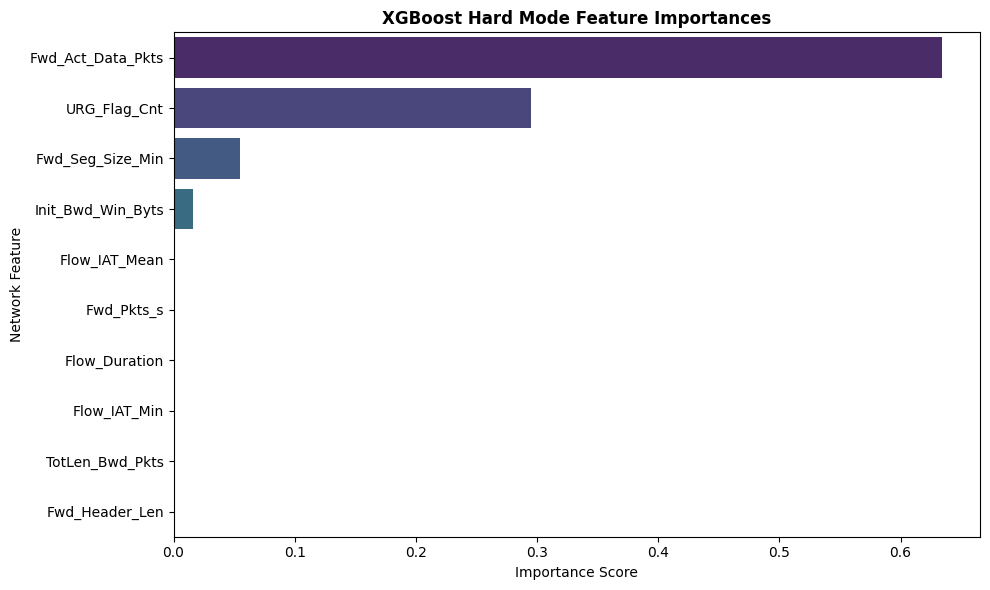

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The exact 35 features that survived the Hard Mode purge
hard_mode_features = ['Flow_Duration', 'Tot_Fwd_Pkts', 'Tot_Bwd_Pkts', 'TotLen_Fwd_Pkts',
       'TotLen_Bwd_Pkts', 'Fwd_Pkt_Len_Max', 'Fwd_Pkt_Len_Mean',
       'Bwd_Pkt_Len_Max', 'Bwd_Pkt_Len_Mean', 'Bwd_Pkt_Len_Std',
       'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min',
       'Fwd_IAT_Tot', 'Fwd_IAT_Max', 'Fwd_Header_Len', 'Bwd_Header_Len',
       'Fwd_Pkts_s', 'Bwd_Pkts_s', 'Pkt_Len_Max', 'Pkt_Len_Mean',
       'Pkt_Len_Std', 'Pkt_Len_Var', 'PSH_Flag_Cnt', 'ACK_Flag_Cnt',
       'URG_Flag_Cnt', 'Down_Up_Ratio', 'Bwd_Seg_Size_Avg',
       'Init_Fwd_Win_Byts', 'Init_Bwd_Win_Byts', 'Fwd_Act_Data_Pkts',
       'Fwd_Seg_Size_Min']

# Safety check to ensure the array shape matches the name list
if X_train.shape[1] != len(hard_mode_features):
    print(f"WARNING: Feature count mismatch! Array has {X_train.shape[1]} columns, but list has {len(hard_mode_features)}.")
else:
    # Extract the importance scores from your Hard Mode model
    importances = xgb_final.feature_importances_

    # Map the scores using our hardcoded list instead of df.columns
    feature_importance_df = pd.DataFrame({
        'Feature': hard_mode_features,
        'Importance': importances
    })

    # Sort to find the new "Cheat Codes"
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("Top 10 Features Driving the 100% Accuracy:")
    print(feature_importance_df.head(10))

    # Visualize it
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='Importance', 
        y='Feature', 
        data=feature_importance_df.head(10), 
        palette='viridis'
    )
    plt.title('XGBoost Hard Mode Feature Importances', fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Network Feature')
    plt.tight_layout()
    plt.show()

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [17]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [18]:
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

validation_dataset = TensorDataset(X_val_tensor, y_val_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [19]:
class IDSNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(IDSNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(hidden_dim, hidden_dim//2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)  

        self.output_layer = nn.Linear(hidden_dim//2, output_dim)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.output_layer(x)
        return x

In [20]:
input_dim = X_train.shape[1]
hidden_dim = 128
output_dim = num_of_classes
model = IDSNN(input_dim, hidden_dim, output_dim).to(device)

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [23]:
epochs = 4
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/4, Loss: 0.0005
Epoch 2/4, Loss: 0.0005
Epoch 3/4, Loss: 0.0005
Epoch 4/4, Loss: 0.0005


In [24]:
model.eval()

IDSNN(
  (fc1): Linear(in_features=34, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (output_layer): Linear(in_features=64, out_features=3, bias=True)
)

In [25]:
all_predictions, all_true_labels = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Move test batch to GPU
        batch_X = batch_X.to(device)
        
        # Get raw mathematical outputs (logits) from the network
        outputs = model(batch_X)
        
        # Find the neuron with the highest probability (the prediction)
        # torch.max returns both the value and the index. We only want the index [1]
        _, predicted_classes = torch.max(outputs, 1)
        
        # Move predictions back to the CPU memory to work with Scikit-Learn
        all_predictions.extend(predicted_classes.cpu().numpy())
        all_true_labels.extend(batch_y.numpy())

y_test_labels = encoder.inverse_transform(all_true_labels)
y_pred_labels = encoder.inverse_transform(all_predictions)

In [26]:
accuracy_score(y_test_labels, y_pred_labels)

0.999980926343898

In [27]:
print(classification_report(y_test_labels, y_pred_labels, digits=4))

                precision    recall  f1-score   support

        Benign     1.0000    1.0000    1.0000    100143
FTP-BruteForce     0.9999    1.0000    1.0000     29004
SSH-Bruteforce     1.0000    0.9999    0.9999     28138

      accuracy                         1.0000    157285
     macro avg     1.0000    1.0000    1.0000    157285
  weighted avg     1.0000    1.0000    1.0000    157285



In [28]:
torch.save(model.state_dict(), ART / 'models/dnn_CICIDS2018.pth')

In [29]:
def create_sliding_windows(X, y, window_size=5):
    X_windows, y_windows = [], []
    for i in range(len(X) - window_size + 1):
        X_windows.append(X[i:i+window_size])
        y_windows.append(y[i+window_size-1])  # Label of the last item in the window
    return np.array(X_windows), np.array(y_windows)

In [30]:
X_train_windows, y_train_windows = create_sliding_windows(X_train, y_train, window_size=10)
X_val_windows, y_val_windows = create_sliding_windows(X_val, y_val, window_size=10)

In [31]:
X_train_windows.shape

(733990, 10, 34)

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
X_train_tensor = torch.tensor(X_train_windows, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_windows, dtype=torch.long).to(device)

X_val_tensor = torch.tensor(X_val_windows, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val_windows, dtype=torch.long).to(device)

In [34]:
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_dataset = TensorDataset(X_val_tensor, y_val_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

In [35]:
class IDSNN_LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2):
        super(IDSNN_LSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
            )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]  # Take the output of the last time step
        lstm_out = self.fc(lstm_out)
        return lstm_out

In [36]:
input_dim = X_train_windows.shape[2]  
hidden_dim = 128
output_dim = num_of_classes
model = IDSNN_LSTM(input_dim, hidden_dim, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [37]:
EPOCHS = 5
PATIENCE = 5

best_val_loss = float('inf')
patience_counter = 0
best_model_state = copy.deepcopy(model.state_dict())

In [38]:
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_time = time.time()

    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in validation_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(validation_loader)

    epoch_duration = time.time() - epoch_time
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Time: {epoch_duration:.2f}s")
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, ART / 'models/best_idsnn_lstm.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break
total_training_time = (time.time() - start_time) / 60
print(f"Total Training Time: {total_training_time:.2f} minutes")

Epoch 1/5 - Loss: 0.0365, Val Loss: 0.0015, Time: 11.71s
Epoch 2/5 - Loss: 0.0015, Val Loss: 0.0010, Time: 11.11s
Epoch 3/5 - Loss: 0.0012, Val Loss: 0.0008, Time: 11.20s
Epoch 4/5 - Loss: 0.0009, Val Loss: 0.0008, Time: 11.36s
Epoch 5/5 - Loss: 0.0008, Val Loss: 0.0007, Time: 11.11s
Total Training Time: 0.95 minutes


In [39]:
X_test_windows, y_test_windows = create_sliding_windows(X_test, y_test, window_size=10) 
X_test_tensor = torch.tensor(X_test_windows, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_windows, dtype=torch.long)

In [40]:
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [41]:
model.load_state_dict(torch.load(ART / 'models/best_idsnn_lstm.pth'))
model.to(device)

IDSNN_LSTM(
  (lstm): LSTM(34, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [42]:
model.eval()

IDSNN_LSTM(
  (lstm): LSTM(34, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [43]:
lstm_predictions, lstm_true_labels = [], []
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        _, predicted_classes = torch.max(outputs, 1)
        lstm_predictions.extend(predicted_classes.cpu().numpy())
        lstm_true_labels.extend(batch_y.numpy())
lstm_true_labels = encoder.inverse_transform(lstm_true_labels)
lstm_pred_labels = encoder.inverse_transform(lstm_predictions)

In [44]:
accuracy_score(lstm_true_labels, lstm_pred_labels)

0.9999427757572675

In [45]:
print(classification_report(lstm_true_labels, lstm_pred_labels, digits=4))

                precision    recall  f1-score   support

        Benign     1.0000    0.9999    1.0000    100139
FTP-BruteForce     0.9998    1.0000    0.9999     29002
SSH-Bruteforce     0.9999    0.9999    0.9999     28135

      accuracy                         0.9999    157276
     macro avg     0.9999    1.0000    0.9999    157276
  weighted avg     0.9999    0.9999    0.9999    157276



In [46]:
old_file = ART / 'models/best_idsnn_lstm.pth'
new_file = ART / 'models/lstm_CICIDS2018.pth'

if old_file.exists():
    old_file.rename(new_file)
    print(f"Successfully renamed to: {new_file.name}")
else:
    print("The old file does not exist. It may have already been renamed.")

Successfully renamed to: lstm_CICIDS2018.pth
